# Análise de Dados Meteorológicos das Estações Automáticas do INMET

## Objetivo

Efetuar a análise dos dados meteorológicos das estações automáticas do INMET entre 2015 e 2025, realizando limpeza, transformação, análise exploratória e geração de visualizações interativas para identificação de padrões climáticos.

## Introdução

Os [dados históricos](https://portal.inmet.gov.br/dadoshistoricos) e o catálogo das [estações automáticas](https://portal.inmet.gov.br/paginas/catalogoaut) foram obtidos do Portal do Instituto Nacional de Meteorologia (INMET).

## Dados
Os arquivos ".zip" contendo os dados históricos das estações podem ter a estrutura:
```text
arquivo.zip/
├── {ano}/
│   └── arquivo.csv

ou

arquivo.zip/
└── arquivo.csv
```

Os arquivos csv estão nomeados da seguinte forma: ``` INMET_{Região}_{UF}_{Codigo WMO}_{Data inicial}_{Data final}.CSV ```, exemplo
INMET_CO_DF_A001_BRASILIA_01-01-2015_A_31-12-2015.CSV


As 8 primeiras linhas do csv das estações são o cabeçalho com detalhes da estação meteorológica e a partir da 9a. linha o cabeçalho das colunas e os dados.

Efetuando a importação das bibliotecas necessárias.

Os comandos *load_ext* e *autorelod* ativam o recarregamento automático de módulos no Jupyter Notebook. Eles garantem que, ao alterar o código de um arquivo .py externo, não necessite reiniciar o kernel para que a célula do notebook reconheça as modificações.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

# Adiciona a raiz do projeto ao path
project_root = os.path.abspath(os.path.join(".."))

if project_root not in sys.path:
    sys.path.append(project_root)


# from src.download_data import baixar_historico_inmet_seguro
from src.process_data import extrair_e_consolidar_inmet

# Oculta avisos de depreciação
warnings.filterwarnings('ignore')

In [2]:
PASTA_DADOS = os.path.join(project_root,"data")          # Arquivos baixados da PRF
PASTA_REPORTS = os.path.join(project_root,"reports")
PASTA_GRAFICOS = os.path.join(project_root,"reports","figures")
ARQUIVO_SAIDA = os.path.join(project_root,"data","inmet_sul.parquet") # Arquivo unificado para análise

Verifica se o arquivo já existe, caso contrário efetua a importação

In [3]:
if not os.path.exists(ARQUIVO_SAIDA):
    print("Base de dados consolidada não encontrada. Iniciando pipeline de dados...")
    
    # Baixa os arquivos ZIP
    #baixar_historico_inmet_seguro(ano_inicio=2015, ano_fim=2025, pasta_destino="../data")
    
    # Processa os ZIPs e gera o arquivo parquet
    extrair_e_consolidar_inmet(pasta_zips="../data/zip", codigo_estacao="S", arquivo_saida="../data/inmet_sul.parquet")
else:
    print(f"O arquivo '{ARQUIVO_SAIDA}' já existe. Carregando dados direto para a memória...")


O arquivo 'f:\Projetos\INMET\data\inmet_sul.parquet' já existe. Carregando dados direto para a memória...


In [4]:
# Lê o arquivo Parquet
df = pd.read_parquet(ARQUIVO_SAIDA)

## Avaliação dos Dados
Com os dados carregados será efetuado uma avaliação para verificar a qualidade dos registros, isto é se há valores NaN e se valores de data e hora estão no formato correto

In [5]:
# Exibe as primeiras linhas e informações básicas para validar a carga
print(f"\nTotal de registros carregados: {len(df):,}")
display(df.head())


Total de registros carregados: 8,891,352


,data,hora_utc,precipitacao,pressao_atmosferica,pressao_atmosferica_maxima,pressao_atmosferica_minima,radiacao,temperatura_ar,temperatura_orvalho,temperatura_maxima,...,umidade_relativa,vento_direcao,vento_rajada,vento_velocidade,nome_estacao,codigo_wmo,uf,latitude,longitude,altitude
0,2015-01-01,00:00,0.0,910.3,910.7,910.1,NaN,20.2,16.6,20.4,...,80.0,265.0,8.5,2.6,CURITIBA,A807,PR,"-25,43333333","-49,26666666","923,5"
1,2015-01-01,01:00,0.0,910.0,910.3,909.9,NaN,20.1,16.8,20.2,...,81.0,306.0,4.5,1.4,CURITIBA,A807,PR,"-25,43333333","-49,26666666","923,5"
2,2015-01-01,02:00,0.0,910.3,910.5,909.9,NaN,20.1,16.9,20.2,...,82.0,302.0,4.1,1.7,CURITIBA,A807,PR,"-25,43333333","-49,26666666","923,5"
3,2015-01-01,03:00,0.0,909.6,910.3,909.5,NaN,20.4,16.3,20.4,...,77.0,331.0,4.1,0.9,CURITIBA,A807,PR,"-25,43333333","-49,26666666","923,5"
4,2015-01-01,04:00,0.0,908.9,909.6,908.9,NaN,20.3,15.9,20.4,...,76.0,299.0,3.4,0.9,CURITIBA,A807,PR,"-25,43333333","-49,26666666","923,5"


In [6]:
display(df.tail())

,data,hora_utc,precipitacao,pressao_atmosferica,pressao_atmosferica_maxima,pressao_atmosferica_minima,radiacao,temperatura_ar,temperatura_orvalho,temperatura_maxima,...,umidade_relativa,vento_direcao,vento_rajada,vento_velocidade,nome_estacao,codigo_wmo,uf,latitude,longitude,altitude
8891347,2025/12/31,1900 UTC,0.0,898.7,899.4,898.7,1715.2,24.0,21.4,24.1,...,85.0,351.0,4.6,1.1,CAMPOS NOVOS,A898,SC,"-27,3886111","-51,21583333",963
8891348,2025/12/31,2000 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,CAMPOS NOVOS,A898,SC,"-27,3886111","-51,21583333",963
8891349,2025/12/31,2100 UTC,0.0,897.6,898.3,897.6,628.2,23.8,20.3,24.4,...,81.0,193.0,3.0,1.1,CAMPOS NOVOS,A898,SC,"-27,3886111","-51,21583333",963
8891350,2025/12/31,2200 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,CAMPOS NOVOS,A898,SC,"-27,3886111","-51,21583333",963
8891351,2025/12/31,2300 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,CAMPOS NOVOS,A898,SC,"-27,3886111","-51,21583333",963


Verifica-se que a coluna *data* apesar de apresentar o formato ano mês dia, não há um separador padrão. 
Para a coluna *hora_utc* também não há uma padronização, variando entre *hh:mm* e *hhmm UTC*

A seguir, será realizado o ajuste para padronizar ambas as colunas.

In [7]:
# Padroniza a formatação das datas que possuem separadores variando "-" e "/"

df['data'] = pd.to_datetime(
    df['data'].astype(str).str.replace('/', '-'), 
    format='%Y-%m-%d', 
    errors='coerce'
)

In [8]:
# Limpa o texto diretamente na coluna original
df['hora_utc'] = (
    df['hora_utc']
    .str.replace('UTC', '', regex=False)
    .str.replace(':', '', regex=False)
    .str.strip()
)

# Transforma em tempo na própria coluna
# O errors='coerce' transforma qualquer texto inválido/corrompido em NaT (Not a Time) em vez de quebrar o código
df['hora_utc'] = pd.to_datetime(df['hora_utc'], format='%H%M', errors='coerce').dt.time


Verificando o dataframe após as correções

In [9]:
df.head()

,data,hora_utc,precipitacao,pressao_atmosferica,pressao_atmosferica_maxima,pressao_atmosferica_minima,radiacao,temperatura_ar,temperatura_orvalho,temperatura_maxima,...,umidade_relativa,vento_direcao,vento_rajada,vento_velocidade,nome_estacao,codigo_wmo,uf,latitude,longitude,altitude
0,2015-01-01,00:00:00,0.0,910.3,910.7,910.1,NaN,20.2,16.6,20.4,...,80.0,265.0,8.5,2.6,CURITIBA,A807,PR,"-25,43333333","-49,26666666","923,5"
1,2015-01-01,01:00:00,0.0,910.0,910.3,909.9,NaN,20.1,16.8,20.2,...,81.0,306.0,4.5,1.4,CURITIBA,A807,PR,"-25,43333333","-49,26666666","923,5"
2,2015-01-01,02:00:00,0.0,910.3,910.5,909.9,NaN,20.1,16.9,20.2,...,82.0,302.0,4.1,1.7,CURITIBA,A807,PR,"-25,43333333","-49,26666666","923,5"
3,2015-01-01,03:00:00,0.0,909.6,910.3,909.5,NaN,20.4,16.3,20.4,...,77.0,331.0,4.1,0.9,CURITIBA,A807,PR,"-25,43333333","-49,26666666","923,5"
4,2015-01-01,04:00:00,0.0,908.9,909.6,908.9,NaN,20.3,15.9,20.4,...,76.0,299.0,3.4,0.9,CURITIBA,A807,PR,"-25,43333333","-49,26666666","923,5"


In [10]:
df.tail()

,data,hora_utc,precipitacao,pressao_atmosferica,pressao_atmosferica_maxima,pressao_atmosferica_minima,radiacao,temperatura_ar,temperatura_orvalho,temperatura_maxima,...,umidade_relativa,vento_direcao,vento_rajada,vento_velocidade,nome_estacao,codigo_wmo,uf,latitude,longitude,altitude
8891347,2025-12-31,19:00:00,0.0,898.7,899.4,898.7,1715.2,24.0,21.4,24.1,...,85.0,351.0,4.6,1.1,CAMPOS NOVOS,A898,SC,"-27,3886111","-51,21583333",963
8891348,2025-12-31,20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,CAMPOS NOVOS,A898,SC,"-27,3886111","-51,21583333",963
8891349,2025-12-31,21:00:00,0.0,897.6,898.3,897.6,628.2,23.8,20.3,24.4,...,81.0,193.0,3.0,1.1,CAMPOS NOVOS,A898,SC,"-27,3886111","-51,21583333",963
8891350,2025-12-31,22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,CAMPOS NOVOS,A898,SC,"-27,3886111","-51,21583333",963
8891351,2025-12-31,23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,CAMPOS NOVOS,A898,SC,"-27,3886111","-51,21583333",963


Correções efetuadas, agora é necessário verificar como estão os registros nulos (NaN)

In [11]:
# Verificando a quantidade de valores ausentes (NaN)
print(df.isna().sum())

data                                0
hora_utc                            0
precipitacao                  1516930
pressao_atmosferica           1208246
pressao_atmosferica_maxima    1214355
pressao_atmosferica_minima    1214387
radiacao                      4537613
temperatura_ar                1218338
temperatura_orvalho           1538624
temperatura_maxima            1224562
temperatura_minima            1224833
temperatura_orvalho_maxima    1551111
temperatura_orvalho_minima    1555403
umidade_relativa_maxima       1552615
umidade_relativa_minima       1559302
umidade_relativa              1549952
vento_direcao                 1555277
vento_rajada                  1562555
vento_velocidade              1566873
nome_estacao                    78888
codigo_wmo                          0
uf                                  0
latitude                            0
longitude                           0
altitude                            0
dtype: int64


Há muitos valores NaN conforme observado acima. Para ficar com o dataframe "limpo" de forma que permita análise, serão excluídas todas as linhas cujas colunas especificadas possuam valor NaN.

In [12]:
# Exclui os registros cujas principais colunas possuam NaN e cria uma cópia em novo dataframe
df_limpo = df.dropna(subset=[
    'precipitacao',
    'pressao_atmosferica',
    'pressao_atmosferica_maxima',
    'pressao_atmosferica_minima',
    'radiacao',
    'temperatura_ar',
    'temperatura_orvalho_maxima',
    'temperatura_orvalho_minima',
    'umidade_relativa_maxima',
    'umidade_relativa_minima',
    'umidade_relativa',
    'vento_direcao',
    'vento_rajada',
    'vento_velocidade'
    ]).copy()

Verificando o dataframe após a remoção dos valores nulos

In [13]:
print(f"\nTotal de registros restantes: {len(df_limpo):,}")

# Verificando valores ausentes após a limpeza
print(df_limpo.isna().sum())


Total de registros restantes: 3,772,981
data                              0
hora_utc                          0
precipitacao                      0
pressao_atmosferica               0
pressao_atmosferica_maxima        0
pressao_atmosferica_minima        0
radiacao                          0
temperatura_ar                    0
temperatura_orvalho               2
temperatura_maxima               13
temperatura_minima               37
temperatura_orvalho_maxima        0
temperatura_orvalho_minima        0
umidade_relativa_maxima           0
umidade_relativa_minima           0
umidade_relativa                  0
vento_direcao                     0
vento_rajada                      0
vento_velocidade                  0
nome_estacao                  27362
codigo_wmo                        0
uf                                0
latitude                          0
longitude                         0
altitude                          0
dtype: int64


Foram eliminados mais de 5 milhões de registros cujas colunas possuiam registros nulos (NaN), mas ainda há estações sem nome.

Verificando quais os códigos das estações estão sem o nome da estação.

In [14]:
df_limpo['uf'][df_limpo['nome_estacao'].isna()].unique()

<ArrowStringArray>
['PR', 'RS']
Length: 2, dtype: str

De acordo com pesquisa:

- A estação A847 era a Estação Meteorológica Automática instalada pelo INMET na Ilha do Mel (município de Paranaguá - PR).
Foi Inaugurada em 23/03/2007 e foi desativada pelo instituto em 2018.
- A estação A808 era a Estação Meteorológica Automática de Torres, localizada no litoral norte do estado do Rio Grande do Sul. Devido aos severos danos materiais causados aos sensores e à estrutura de transmissão por atos de vandalismo, ela foi fechada em 10 de outubro de 2024.

Atualizando o dataframe para incluir o nome destas estações.

In [15]:
mapeamento = {'A847': 'ILHA DO MEL', 'A808': 'TORRES'}

# Atualiza nome_estacao onde houver correspondência em codigo_wmo
df_limpo['nome_estacao'] = df_limpo['codigo_wmo'].map(mapeamento).fillna(df_limpo['nome_estacao'])

In [16]:
# Efetuando nova verificação se todas as estações estão completas
print(df_limpo.isna().sum())

data                           0
hora_utc                       0
precipitacao                   0
pressao_atmosferica            0
pressao_atmosferica_maxima     0
pressao_atmosferica_minima     0
radiacao                       0
temperatura_ar                 0
temperatura_orvalho            2
temperatura_maxima            13
temperatura_minima            37
temperatura_orvalho_maxima     0
temperatura_orvalho_minima     0
umidade_relativa_maxima        0
umidade_relativa_minima        0
umidade_relativa               0
vento_direcao                  0
vento_rajada                   0
vento_velocidade               0
nome_estacao                   0
codigo_wmo                     0
uf                             0
latitude                       0
longitude                      0
altitude                       0
dtype: int64


### Análise dos Dados

In [17]:
# Média das temperaturas máximas e mínims
print(f"Média das temperaturas máximas: {df_limpo['temperatura_maxima'].mean():.2f}".replace('.',',')+" °C")
print(f"Média das temperaturas mínimas:{df_limpo['temperatura_minima'].mean():.2f}".replace('.',',')+ " °C")

Média das temperaturas máximas: 21,66 °C
Média das temperaturas mínimas:20,16 °C


In [18]:
# Máximos e mínimos das temperaturas
print(f"Temperatura máxima registrada: {df_limpo['temperatura_maxima'].max():.2f}".replace('.',',')+" °C")
print(f"Temperatura mínima registrada: {df_limpo['temperatura_minima'].min():.2f}".replace('.',',')+" °C")

Temperatura máxima registrada: 44,70 °C
Temperatura mínima registrada: -8,50 °C


Será criado um dataframe para agrupar as temperaturas máximas e mínimas por estado para plotar os dados no formato de gráfico de halteres (Dunbbell)

In [19]:
# Localiza os índices com menores e maiores temperaturas por uf
idx_min = df_limpo.groupby('uf')['temperatura_minima'].idxmin()
idx_max = df_limpo.groupby('uf')['temperatura_maxima'].idxmax()

# Filtra o DataFrame original para mostrar apenas essas linhas específicas com todas as colunas
df_minimas = df_limpo.loc[idx_min]
df_maximas = df_limpo.loc[idx_max]

df_minimas['tipo_extremo'] = 'Mínima'
df_maximas['tipo_extremo'] = 'Máxima'


In [20]:
df_minimas[['data','codigo_wmo','temperatura_minima']]

,data,codigo_wmo,temperatura_minima
1713587,2021-07-20,A875,-7.9
6168947,2016-06-12,A894,-5.1
2195598,2021-07-29,A845,-8.5


In [21]:
# Junta os dois DataFrames pela coluna 'uf' para ter a mínima e máxima na mesma linha
df_junto = pd.merge(df_minimas[['uf', 'temperatura_minima']], 
                    df_maximas[['uf', 'temperatura_maxima']], 
                    on='uf').sort_values(by='temperatura_maxima')

O merge combina os dois DataFrames (df_minimas e df_maximas) em um novo que contém todas as colunas de ambos combinadas onde os valores da coluna *uf* são iguais.

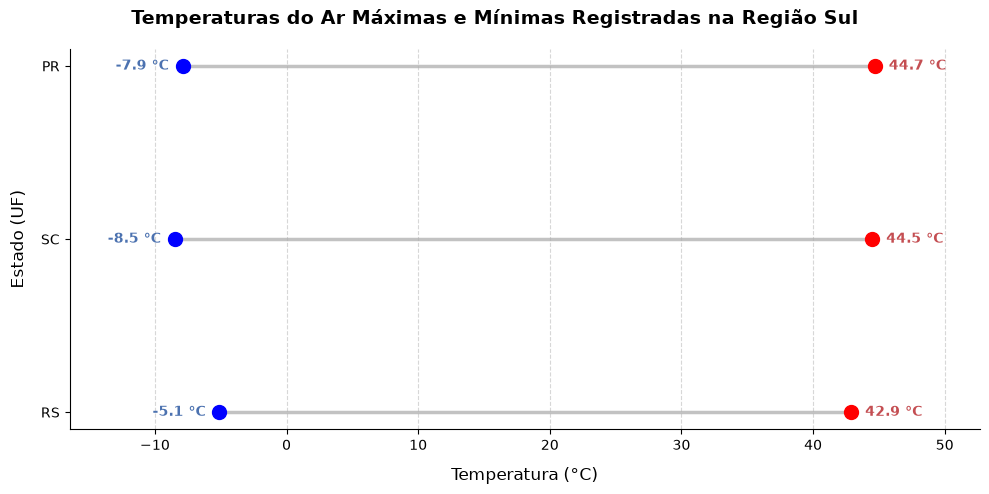

In [22]:
diretorio_imagem = os.path.join(PASTA_GRAFICOS, 'fig_maximas_minimas_uf')

plt.close('all') # Fecha qualquer gráfico residual da memória

fig, ax = plt.subplots(figsize=(10, 5))


# Desenha as linhas do haltere
ax.hlines(y=df_junto['uf'], xmin=df_junto['temperatura_minima'], xmax=df_junto['temperatura_maxima'], color='darkgrey', linewidth=2.5, alpha=0.7, zorder=1)

# Desenha as duas pontas do haltere
ax.scatter(df_junto['temperatura_minima'], df_junto['uf'], color='blue', label='Mínima', s=100)
ax.scatter(df_junto['temperatura_maxima'], df_junto['uf'], color='red', label='Máxima', s=100)

for index, row in df_junto.iterrows():
    # Rótulo para a Temperatura Mínima (afastado 10 pontos para a esquerda)
    ax.annotate(f"{row['temperatura_minima']} °C", 
                xy=(row['temperatura_minima'], row['uf']), # Coordenada exata do ponto
                xytext=(-10, 0),                           # -10 pontos na horizontal, 0 na vertical
                textcoords="offset points",                # Tipo de deslocamento (pixels/pontos)
                va='center', ha='right', 
                fontsize=10, fontweight='bold', color='#4C72B0')
    
    # Rótulo para a Temperatura Máxima (afastado 10 pontos para a direita)
    ax.annotate(f"{row['temperatura_maxima']} °C", 
                xy=(row['temperatura_maxima'], row['uf']), # Coordenada exata do ponto
                xytext=(10, 0),                            # +10 pontos na horizontal, 0 na vertical
                textcoords="offset points",                # Tipo de deslocamento (pixels/pontos)
                va='center', ha='left', 
                fontsize=10, fontweight='bold', color='#C44E52')
    
    # Adiciona margem para o número não ficar sobreposto ao eixo
    ax.margins(x=0.15)

# Estética
ax.set_xlabel('Temperatura (°C)', fontsize=12, labelpad=10)
ax.set_ylabel('Estado (UF)', fontsize=12, labelpad=10)


# Adiciona linhas de grade
ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)

# Remove top and right spines for a modern minimalistic look
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.suptitle('Temperaturas do Ar Máximas e Mínimas Registradas na Região Sul', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(diretorio_imagem, dpi=300, bbox_inches='tight')
plt.show()



In [23]:
# Concatena os DataFrames já identificados
df_extremos = pd.concat([df_minimas, df_maximas], ignore_index=True, axis=0)

#  Ordena por UF para ver a mínima e a máxima de cada estado lado a lado
df_extremos = df_extremos.sort_values(by=['uf', 'tipo_extremo'])

In [24]:
df_resumo = df_extremos[['data','hora_utc','temperatura_minima','temperatura_maxima','codigo_wmo','nome_estacao','uf']]

In [25]:
display(df_resumo)

,data,hora_utc,temperatura_minima,temperatura_maxima,codigo_wmo,nome_estacao,uf
3,2019-02-18,17:00:00,33.1,44.7,B806,COLOMBO,PR
0,2021-07-20,11:00:00,-7.9,-7.2,A875,GENERAL CARNEIRO,PR
4,2022-02-27,18:00:00,41.0,42.9,A809,URUGUAIANA,RS
1,2016-06-12,11:00:00,-5.1,-3.1,A894,SERAFINA CORREA,RS
5,2019-11-30,17:00:00,32.1,44.5,A870,RANCHO QUEIMADO,SC
2,2021-07-29,06:00:00,-8.5,-7.3,A845,BOM JARDIM DA SERRA - MORRO DA IGREJA,SC


Conforme observado, as menores e maiores temperaturas medidas nas estações meteorológicas no período de 2015 a 2025 na região Sul foram:
- **PR**
    - **Menor temperatura:** General Carneiro, com -7,9 °C no dia 20/07/2021 às 09h.
    - **Maior temperatura:** Colombo, com 44,7 °C no dia 18/02/2019 às 16h.
- **SC**
    - **Menor temperatura:** Bom Jardim da Serra - Morro da Igreja, com -8,5 °C no dia 29/07/2021 às 03h. 
    - **Maior temperatura:** Rancho Queimado, com 44,5 °C no dia 30/11/2019 às 14h
- **RS**
    - **Menor temperatura:** Serafina Correa, com -5,1 °C no dia 12/06/2016 às 08h. 
    - **Maior temperatura:** Uruguaiana, com 42,9 °C no dia 27/02/2022 às 16h.

Observação: Os horários aqui descritos foram transformados para horário de Brasília (UTC-3).

## Comparação das abordagens de visualização

### Amplitudes e Médias para a região Sul

In [26]:
df_mensal_todos = df_limpo.copy()

# Garante que a coluna de data é o índice do DataFrame
df_mensal_todos = df_mensal_todos.set_index('data')

# Reamostra para obter a média, máxima e mínima mensal
# .resample('ME') é usado para agrupar dados de séries temporais com frequência de fim de mês
df_mensal_todos = df_mensal_todos['temperatura_ar'].resample('ME').agg(['mean', 'max', 'min'])

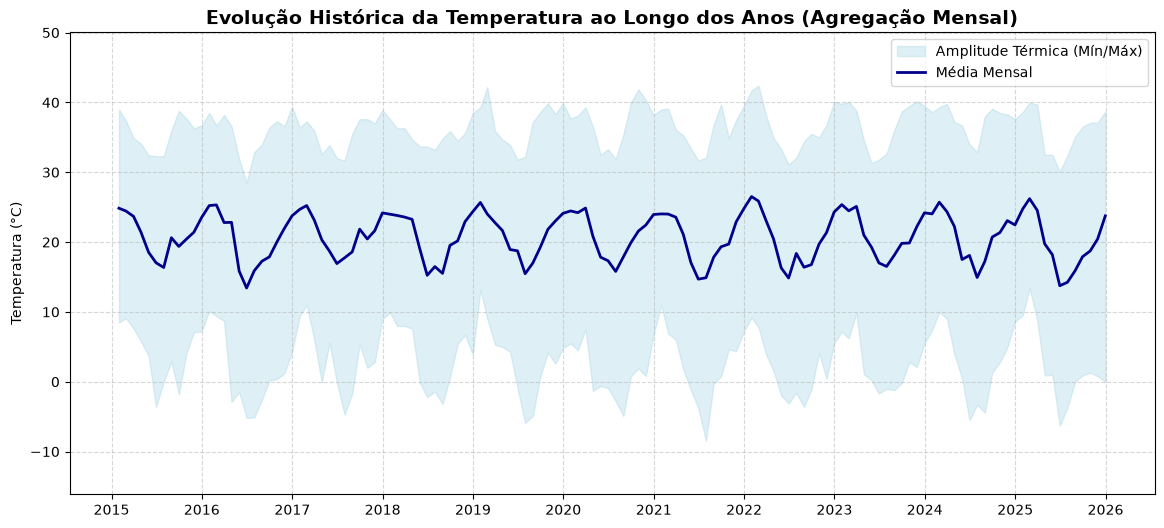

In [27]:
diretorio_imagem = os.path.join(PASTA_GRAFICOS,"fig_temperaturas_ano_agregado.png")


plt.close('all') # Fecha qualquer gráfico residual da memória
fig, ax = plt.subplots(figsize=(14, 6))

# Área sombreada entre a mínima e a máxima (mostra a amplitude térmica)
ax.fill_between(df_mensal_todos.index, df_mensal_todos['min'], df_mensal_todos['max'], 
                color='lightblue', alpha=0.4, label='Amplitude Térmica (Mín/Máx)')
ax.margins(y=0.15)  

# Linha principal com a média mensal
ax.plot(df_mensal_todos.index, df_mensal_todos['mean'], color='darkblue', linewidth=2, label='Média Mensal')

# Configura os anos em sequência (1 em 1)
ax.xaxis.set_major_locator(mdates.YearLocator(base=1)) # Força o intervalo de 1 ano
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Exibe apenas o ano
#plt.xticks(rotation=45) # Rotaciona para os anos se o período for longo

ax.set_title('Evolução Histórica da Temperatura ao Longo dos Anos (Agregação Mensal)', fontsize=14, fontweight='bold')
ax.set_ylabel('Temperatura (°C)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc="upper right", borderaxespad=0.5)

plt.savefig(diretorio_imagem, dpi=300, bbox_inches='tight')
plt.show()

### Estados sobrepostos

**Objetivo:** Comparar rapidamente o comportamento térmico relativo entre Paraná, Santa Catarina e Rio Grande do Sul.



In [28]:
# Copia o dataframe original e agrupa
df_mensal = df_limpo.copy()

# Cria uma coluna de mês
df_mensal['mes'] = df_mensal['data'].dt.month


# O parâmetro freq='ME' (Month End, ou fim do mês) em pd.Grouper agrupa dados de séries temporais 
# em intervalos mensais baseados no calendário, atribuindo a cada grupo como rótulo a data exata 
# do último dia do respectivo mês.
df_mensal = df_mensal.groupby(['uf', pd.Grouper(key='data', freq='ME')])['temperatura_ar'].agg(['mean', 'max', 'min']).reset_index()

# Ordena cronologicamente
df_mensal = df_mensal.sort_values('data')


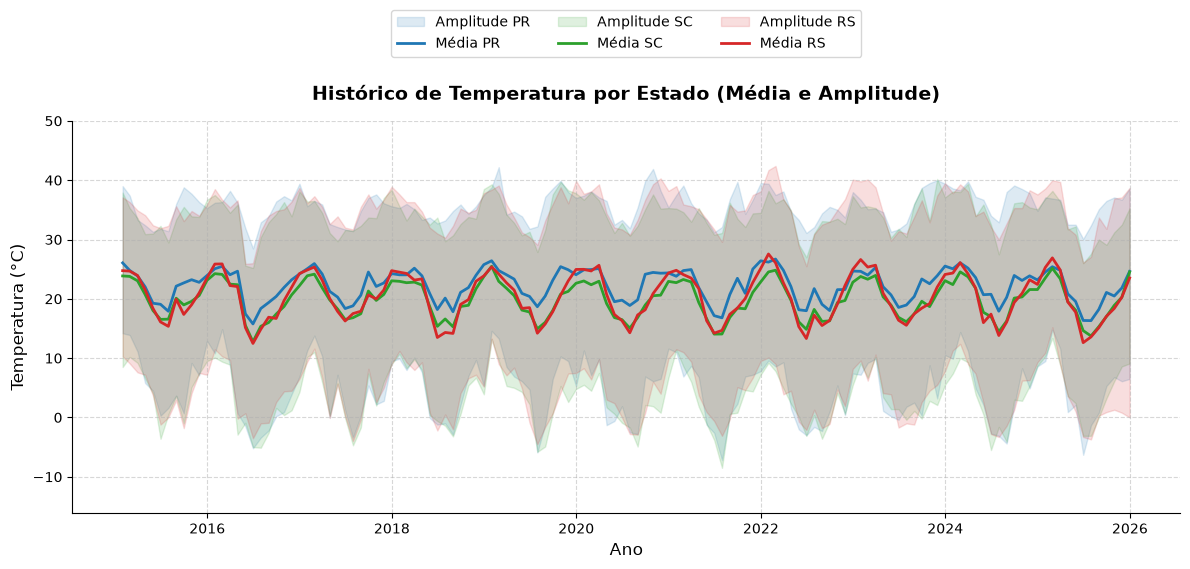

In [29]:
diretorio_imagem = os.path.join(PASTA_GRAFICOS,"fig_temperaturas_ano_estados.png")

plt.close('all') # Fecha qualquer gráfico residual da memória


# Criando a figura do Matplotlib
fig, ax = plt.subplots(figsize=(12, 6))

# Cores personalizadas para identificar cada estado
cores = {
    'PR': {'linha': '#1f77b4', 'area': '#1f77b4'},
    'SC': {'linha': '#2ca02c', 'area': '#2ca02c'},
    'RS': {'linha': '#d62728', 'area': '#d62728'}
}

# Loop para plotar cada estado individualmente
for estado in ['PR', 'SC', 'RS']:
    # Filtra os dados apenas do estado atual do loop
    df_estado = df_mensal[df_mensal['uf'] == estado]
    
    # 1. Área sombreada (Mínima até Máxima)
    ax.fill_between(
        df_estado['data'], 
        df_estado['min'], 
        df_estado['max'], 
        color=cores[estado]['area'], 
        alpha=0.15, # Opacidade bem suave para não poluir
        label=f'Amplitude {estado}',
        zorder=1
    )
    
    # 2. Linha da Média Mensal
    ax.plot(
        df_estado['data'], 
        df_estado['mean'], 
        color=cores[estado]['linha'], 
        linewidth=2, 
        label=f'Média {estado}',
        zorder=2
    )

# Estética do gráfico
ax.set_title('Histórico de Temperatura por Estado (Média e Amplitude)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Temperatura (°C)', fontsize=12)
ax.set_xlabel('Ano', fontsize=12)

# Adiciona margem de 15% no topo/fundo para a legenda não cobrir os dados
ax.margins(y=0.15)

# Linha média de temperatura
"""ax.axhline(
    25,
    color='gray',
    linestyle=':',
    linewidth=1
)"""

# Legenda organizada em 3 colunas no topo para não atrapalhar o visual
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=3, frameon=True)

# Linhas de grade suaves
ax.grid(axis='both', linestyle='--', alpha=0.5)

# Remove as bordas desnecessárias (estilo clean)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Configura os anos em sequência (1 em 1)
ax.xaxis.set_major_locator(mdates.YearLocator(base=2)) # Força o intervalo de 2 anos
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Exibe apenas o ano

plt.tight_layout()
plt.savefig(diretorio_imagem, dpi=300, bbox_inches='tight')
plt.show()

O agrupamento dos 3 estados no mesmo gráfico ficou difícil para avaliar. É possível visualizar que a amplitude mínima, como 2018, foi maior em SC que nos estados do PR e SC, enquanto que para 2021 fica difícil identificar qual estado apresentou menor amplitude devido a sobreposição das cores, aparentado os valores para PR e SC estarem bem próximos.

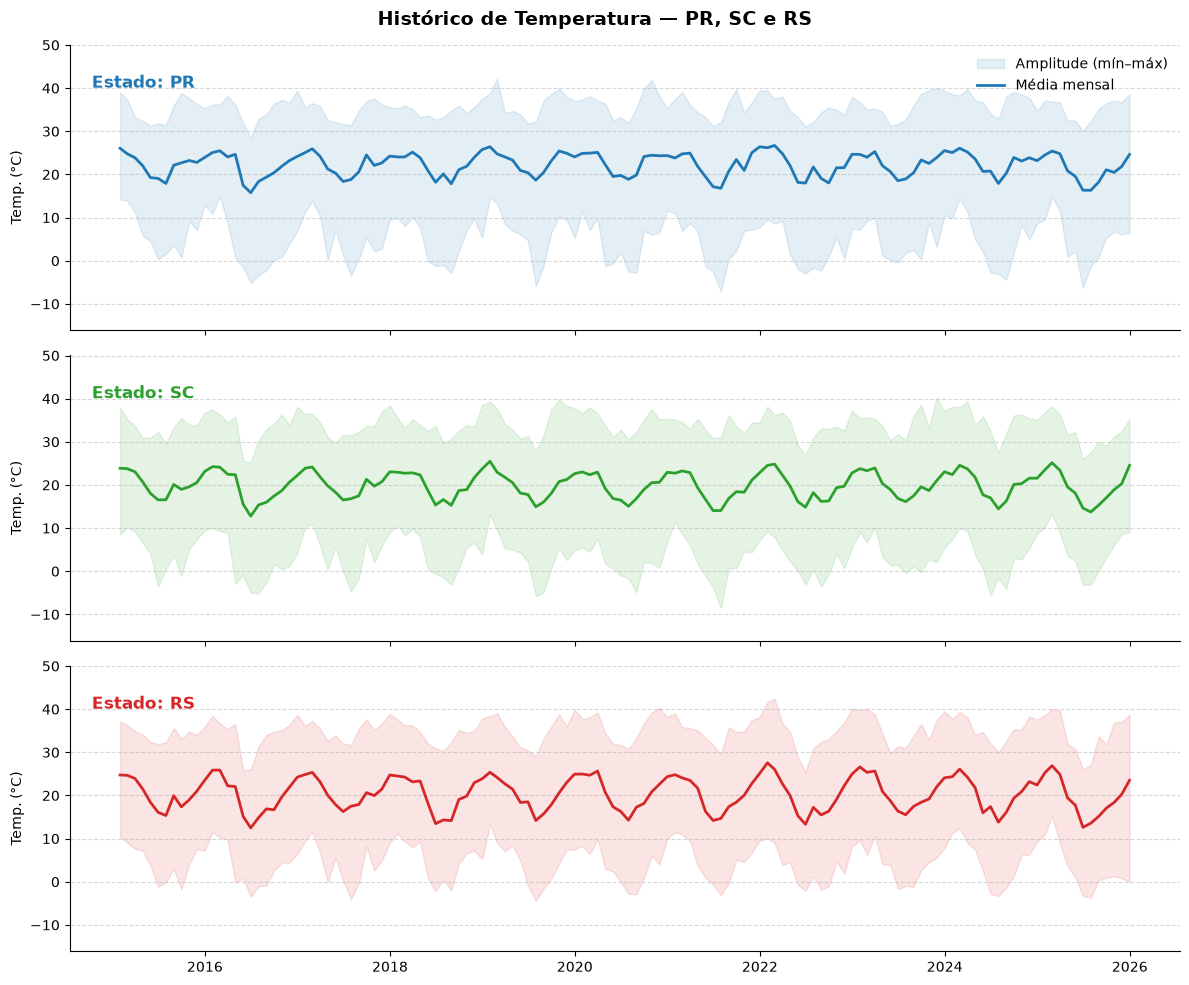

In [30]:
diretorio_imagem = os.path.join(PASTA_GRAFICOS,"fig_temperaturas_estados.png")
estados = ['PR', 'SC', 'RS']

plt.close('all') # Fecha qualquer gráfico residual da memória# Lista de estados únicos

# Cria uma figura com 3 subplots empilhados verticalmente (3 linhas, 1 coluna)
# sharex=True garante que o eixo X (anos) seja idêntico e compartilhado por todos
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True, sharey=True)

# Cores específicas para cada estado
cores = {
    'PR': {'linha': '#1f77b4', 'area': '#1f77b4'},
    'SC': {'linha': '#2ca02c', 'area': '#2ca02c'},
    'RS': {'linha': '#d62728', 'area': '#d62728'}
}

# Loop para desenhar em cada subplot correspondente
for i, estado in enumerate(estados):
    ax = axs[i] # Seleciona o subplot atual (0, 1 ou 2)
    df_estado = df_mensal[df_mensal['uf'] == estado]
    
    # 1. Área sombreada de amplitude (Mínima até Máxima)
    ax.fill_between(
        df_estado['data'], 
        df_estado['min'], 
        df_estado['max'], 
        color=cores[estado]['area'], 
        alpha=0.12,
        label='Amplitude'
    )
    
    # 2. Linha da Média Mensal
    ax.plot(
        df_estado['data'], 
        df_estado['mean'], 
        color=cores[estado]['linha'], 
        linewidth=2, 
        label='Média Mensal'
    )

    axs[-1].xaxis.set_major_locator(
    mdates.YearLocator(2)
    )

    axs[-1].xaxis.set_major_formatter(
        mdates.DateFormatter('%Y')
    )
    
    # Configurações específicas de cada subplot
    ax.set_ylabel('Temp. (°C)', fontsize=10)
    
    # Adiciona um título interno/lateral no subplot para identificar o estado
    ax.text(0.02, 0.85, f'Estado: {estado}', transform=ax.transAxes, 
            fontsize=12, fontweight='bold', color=cores[estado]['linha'])
    
    # Estética limpa para cada subplot
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.margins(y=0.15)
    
    # Remove bordas desnecessárias de cada quadro
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

# Adiciona uma única legenda elegante no topo direito fora da área do gráfico
axs[0].legend(
    ['Amplitude (mín–máx)', 'Média mensal'],
    loc='upper right',
    frameon=False
)

# Título principal da imagem
plt.suptitle('Histórico de Temperatura — PR, SC e RS', fontsize=14, fontweight='bold', y=0.98)

# Ajusta o espaçamento entre os subplots para não encavalarem
plt.tight_layout()
plt.savefig(diretorio_imagem, dpi=300, bbox_inches='tight')
plt.show()

Abaixo será testado as plotagens unificada e separada utilizando a biblioteca plotly para verificar se a visualização se torna melhor.

In [31]:
fig = go.Figure()

# Cores para cada estado para o gráfico ficar organizado
cores = {
    'PR': {'linha': 'rgba(31, 119, 180, 1)', 'area': 'rgba(31, 119, 180, 0.15)'},
    'SC': {'linha': 'rgba(44, 160, 44, 1)', 'area': 'rgba(44, 160, 44, 0.15)'},
    'RS': {'linha': 'rgba(214, 39, 40, 1)', 'area': 'rgba(214, 39, 40, 0.15)'}
}


for estado in df_mensal['uf'].unique():
    # Filtra os dados apenas do estado atual do loop
    df_estado = df_mensal[df_mensal['uf'] == estado]
    
   # Linha da Média (visível)
    fig.add_trace(go.Scatter(
        x=df_estado['data'],
        y=df_estado['mean'],
        mode='lines',
        line=dict(color=cores[estado]['linha'], width=2),
        name=f'Média {estado}',
        customdata=df_estado[['min','max']].values,
        hovertemplate=(
            f"<b>{estado}</b><br>"
            "Máx: %{customdata[1]:.1f}°C<br>"
            "Média: %{y:.1f}°C<br>"
            "Mín: %{customdata[0]:.1f}°C"
            "<extra></extra>"
        )
    ))

    # Linha invisível da Mínima (base para a área sombreada)
    fig.add_trace(go.Scatter(
        x=df_estado['data'],
        y=df_estado['min'],
        mode='lines',
        line=dict(width=0),
        showlegend=False,
        hoverinfo="skip"
    ))
    
    # Área sombreada até a Máxima
    fig.add_trace(go.Scatter(
        x=df_estado['data'],
        y=df_estado['max'],
        mode='lines',
        line=dict(width=0),
        fill='tonexty',
        fillcolor=cores[estado]['area'],
        showlegend=False,
        hoverinfo="skip"
    ))

    # Cria legenda das médias
    """fig.add_trace(go.Scatter(
        x=[None],
        y=[None],
        mode='markers',
        marker=dict(
            color=cores[estado]['area'],
            size=12
        ),
        name=f'Amplitude {estado} (mín-máx)',
        showlegend=True
    ))"""
    
fig.update_xaxes(
    dtick="M24",           # Força o intervalo de 24 meses (2 anos)
    tickformat="%Y",       # Exibe apenas o ano com 4 dígitos
    #tickangle=45           # Rotaciona o texto em 45 graus se necessário
)

# Customização final do layout
fig.update_layout(
    title=dict(text='Evolução Histórica da Temperatura (PR, SC e RS)', x=0.5),
    #xaxis_title='Ano',
    yaxis_title='Temperatura (°C)',
    hovermode='x unified',
    plot_bgcolor='white',
    height=600
)
fig.add_annotation(
    text="Linhas: temperatura média | Áreas: intervalo mínimo–máximo",
    xref="paper",
    yref="paper",
    x=0,
    y=-0.15,
    showarrow=False
)

fig.update_xaxes(showgrid=True, gridcolor='LightGrey')
fig.update_yaxes(showgrid=True, gridcolor='LightGrey')

fig.show()

Com o plotly apesar de ainda continuar visualmente confuso tem-se a vantagem da exibição dos detalhes das médias e amplitudes da temperatura ao mover o cursor sobre o gráfico.

### Múltiplos pequenos por estado

**Objetivo:** Analisar a distribuição térmica individual de cada estado, destacando amplitude entre mínimas e máximas.

In [32]:
fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=("Paraná", "Santa Catarina", "Rio Grande do Sul")
)

cores = {
    'PR': {'linha': 'rgb(31,119,180)', 'area': 'rgba(31,119,180,0.15)'},
    'SC': {'linha': 'rgb(44,160,44)', 'area': 'rgba(44,160,44,0.15)'},
    'RS': {'linha': 'rgb(214,39,40)', 'area': 'rgba(214,39,40,0.15)'}
}

estados = ["PR", "SC", "RS"]

for i, estado in enumerate(estados, start=1):

    df_estado = df_mensal[df_mensal["uf"] == estado]

    # média
    fig.add_trace(
        go.Scatter(
            x=df_estado["data"],
            y=df_estado["mean"],
            mode="lines",
            line=dict(color=cores[estado]["linha"], width=2.5),
            name=f"Média {estado}",
            xhoverformat="%b %Y",
            hovertemplate="Média: %{y:.1f}°C<extra></extra>",
            #hovertemplate="<b>%{x|%b %Y}</b><br>Média: %{y:.1f}°C<extra></extra>"
        ),
        row=i, col=1
    )

    # mínima (invisível)
    fig.add_trace(
        go.Scatter(
            x=df_estado["data"],
            y=df_estado["min"],
            mode="lines",
           line=dict(
                color=cores[estado]['linha'],
                width=1,
                dash='dot'      # ou 'dash'
            ),
            showlegend=False,
            xhoverformat="%b %Y",
            hovertemplate="Mín: %{y:.1f}°C<extra></extra>",
            #hovertemplate="<b>%{x|%b %Y}</b><br>Mín: %{y:.1f}°C<extra></extra>"
        ),
        row=i, col=1
    )

    # máxima preenchendo até a mínima
    fig.add_trace(
        go.Scatter(
            x=df_estado["data"],
            y=df_estado["max"],
            mode="lines",
            line=dict(
                color=cores[estado]['linha'],
                width=1,
                dash='dot'
            ),
            fill="tonexty",
            fillcolor=cores[estado]["area"],
            name=f"Amplitude {estado}",
            xhoverformat="%b %Y",
            hovertemplate="Máx: %{y:.1f}°C<extra></extra>",
            #hovertemplate="<b>%{x|%b %Y}</b><br>Máx: %{y:.1f}°C<extra></extra>"
        ),
        row=i, col=1
    )


# Configuração do layout geral e do Hover Sincronizado com Caixas Separadas
fig.update_layout(
    title="Evolução Histórica das Temperaturas por Estado",
    height=900,
    hovermode="x",             # Mantém as caixas flutuantes separadas por gráfico
    plot_bgcolor="white",
    hoverlabel=dict(
        bgcolor="white",
        font_size=12
    )
)



fig.update_xaxes(
    dtick="M12", # Exibe o rótulo de x com intervalos de 1 ano
    tickformat="%Y",
    showgrid=True,
    gridcolor="lightgray",
    showspikes=True,
    spikesnap="cursor",
    spikecolor="gray",
    spikethickness=1,
    spikedash="solid",
    spikemode="across",
    hoverformat="%b %Y"
)

# Atualiza o eixo x para exibir os rótulos de ano apenas no último gráfico
fig.update_xaxes(showticklabels=False, row=1, col=1)
fig.update_xaxes(showticklabels=False, row=2, col=1)
fig.update_xaxes(showticklabels=True, row=3, col=1)



# Configurações de grade dos eixos Y individuais
fig.update_yaxes(
    showgrid=True, 
    gridcolor="lightgray", 
    title="°C", 
    range=[-10, 45]
)

fig.show()

O gráfico agregado facilita a comparação entre estados, porém apresenta maior carga visual devido à sobreposição das amplitudes térmicas. A abordagem em painéis separados reduz a interferência visual e é mais adequada para análise individual das séries históricas.


Com os 3 estados separados a análise das médias e amplitudes mensais se torna mais fácil. 

Comparando o plotly e matplotlib, o primeiro traz a vantagem do hover, que exibe os valores mensais e é indicado para saber exatamente as temperaturas em determinado ponto do gráfico. 

O matplotlib traz a informção visual, mas não permite avaliar com exatidão as variações da temperatura; se plotar os valores no gráfico ficará com excesso de informação.

In [33]:
# Copia o dataframe limpo em novo dataframe
df_mapa = df_limpo.copy()

In [34]:
# Filtra o dataframe para o estado do PR
df_pr = df_mapa[df_mapa['uf'] == 'PR']

# Extrai o Mês em coluna separada
df_pr['mes'] = df_pr['data'].dt.month

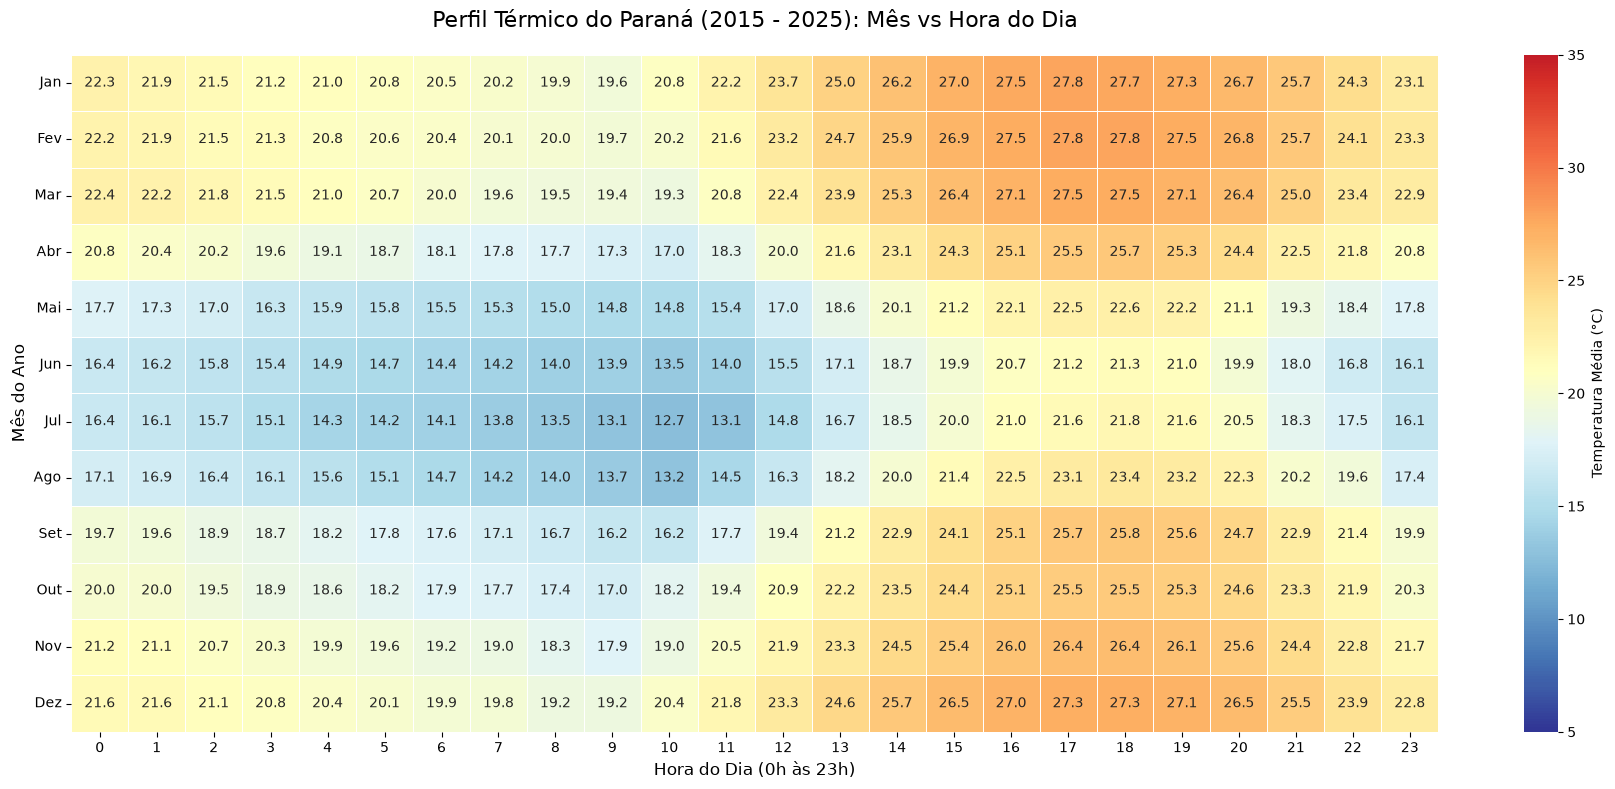

In [35]:
diretorio_imagem = os.path.join(PASTA_GRAFICOS,"fig_mapa_calor_PR.png")

plt.close('all') # Fecha qualquer gráfico residual da memória# Lista de estados únicos

# Agrupa os dados por Mês e Hora e calcula a média da temperatura
# O pivot_table já faz o agrupamento (média) automaticamente para valores duplicados
df_pivot_pr = df_pr.pivot_table(index='mes', columns='hora_utc', values='temperatura_ar', aggfunc='mean')

# Garante que os meses estão ordenados corretamente
df_pivot_pr = df_pivot_pr.reindex(range(1,13))

# Configura e desenha o Heatmap
plt.figure(figsize=(18, 8))

# Cria o heatmap usando uma paleta térmica ('coolwarm' é ideal para temperatura)
sns.heatmap(
    df_pivot_pr, 
    cmap='RdYlBu_r', 
    vmin=5,
    vmax=35,
    center=21,
    annot=True, 
    fmt=".1f", 
    linewidths=.5, 
    cbar_kws={'label': 'Temperatura Média (°C)'})

# Títulos e formatação dos eixos
plt.title('Perfil Térmico do Paraná (2015 - 2025): Mês vs Hora do Dia', fontsize=16, pad=20)
plt.xlabel('Hora do Dia (0h às 23h)', fontsize=12)
plt.ylabel('Mês do Ano', fontsize=12)

# Substitui os números dos meses pelos nomes para melhor leitura
nomes_meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
plt.yticks(ticks=np.arange(12) + 0.5, labels=nomes_meses, rotation=0)
plt.xticks(ticks=np.arange(24) + 0.5, labels=list(range(24)), rotation=0)

# Exibir o gráfico
plt.tight_layout()
plt.savefig(diretorio_imagem, dpi=300, bbox_inches='tight')
plt.show()


In [36]:
# Filtra o dataframe para o estado de SC
df_sc = df_mapa[df_mapa['uf'] == 'SC']

# Extrai o Mês em coluna separada
df_sc['mes'] = df_sc['data'].dt.month

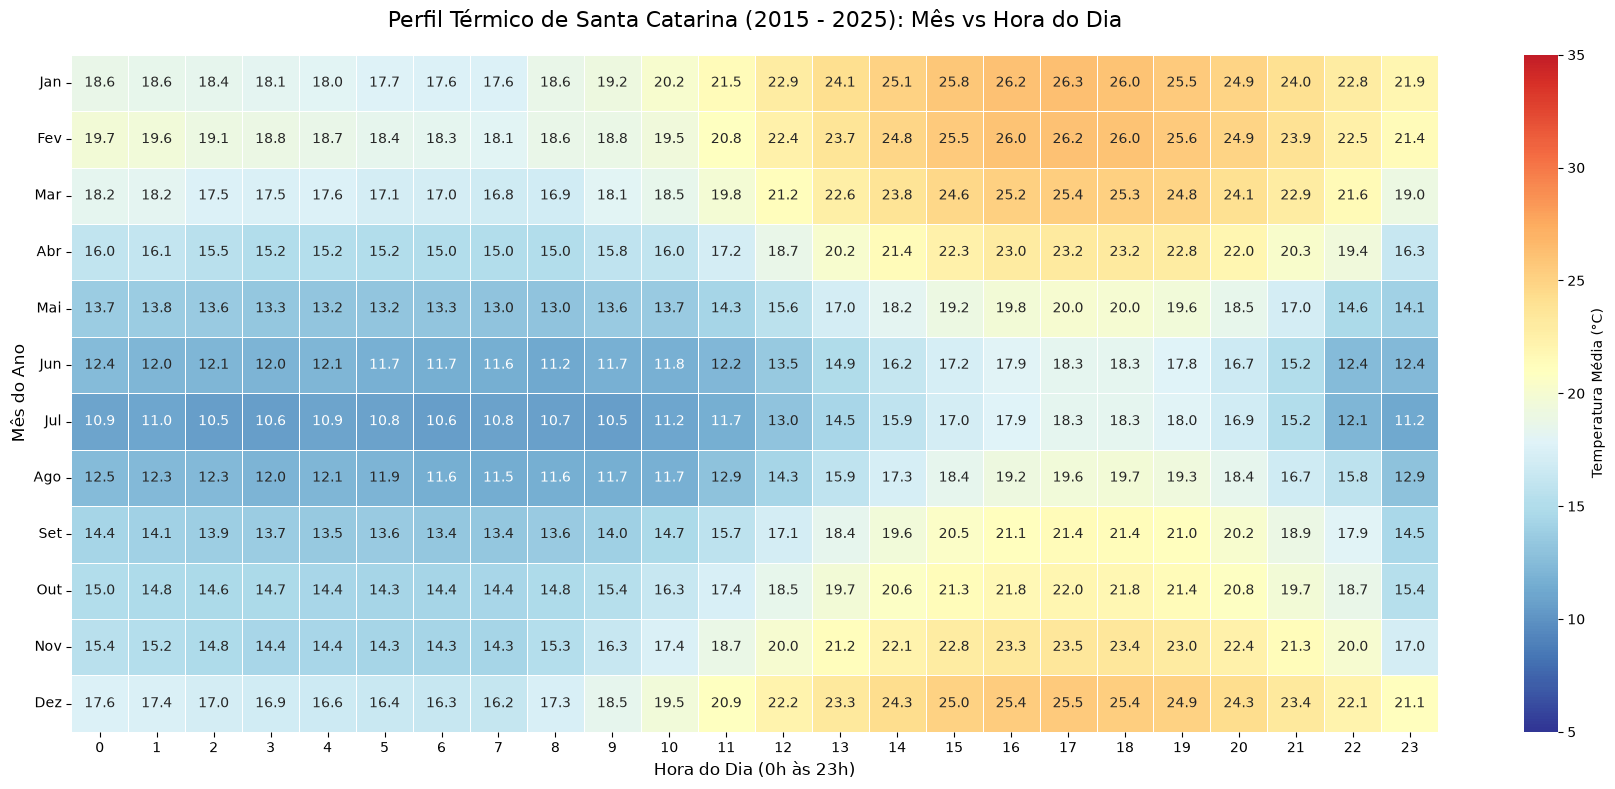

In [37]:
diretorio_imagem = os.path.join(PASTA_GRAFICOS,"fig_mapa_calor_SC.png")

plt.close('all') # Fecha qualquer gráfico residual da memória# Lista de estados únicos

# Agrupa os dados por Mês e Hora e calcula a média da temperatura
# O pivot_table já faz o agrupamento (média) automaticamente para valores duplicados
df_pivot_sc = df_sc.pivot_table(index='mes', columns='hora_utc', values='temperatura_ar', aggfunc='mean')

# Garante que os meses estão ordenados corretamente
df_pivot_sc = df_pivot_sc.reindex(range(1,13))

# 4. Configurar e desenhar o Heatmap
plt.figure(figsize=(18, 8))

# Criar o heatmap usando uma paleta térmica ('coolwarm' é ideal para temperatura)
sns.heatmap(
    df_pivot_sc, 
    cmap='RdYlBu_r', 
    vmin=5,
    vmax=35,
    center=21,
    annot=True, 
    fmt=".1f", 
    linewidths=.5, 
    cbar_kws={'label': 'Temperatura Média (°C)'}
)

# Títulos e formatação dos eixos
plt.title('Perfil Térmico de Santa Catarina (2015 - 2025): Mês vs Hora do Dia', fontsize=16, pad=20)
plt.xlabel('Hora do Dia (0h às 23h)', fontsize=12)
plt.ylabel('Mês do Ano', fontsize=12)

# Substituir os números dos meses pelos nomes para melhor leitura
nomes_meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
plt.yticks(ticks=np.arange(12) + 0.5, labels=nomes_meses, rotation=0)
plt.xticks(ticks=np.arange(24) + 0.5, labels=list(range(24)), rotation=0)

# Exibir o gráfico
plt.tight_layout()
plt.savefig(diretorio_imagem, dpi=300, bbox_inches='tight')
plt.show()

In [38]:
# Filtra o dataframe para o estado de SC
df_rs = df_mapa[df_mapa['uf'] == 'RS']

# Extrai o Mês em coluna separada
df_rs['mes'] = df_rs['data'].dt.month

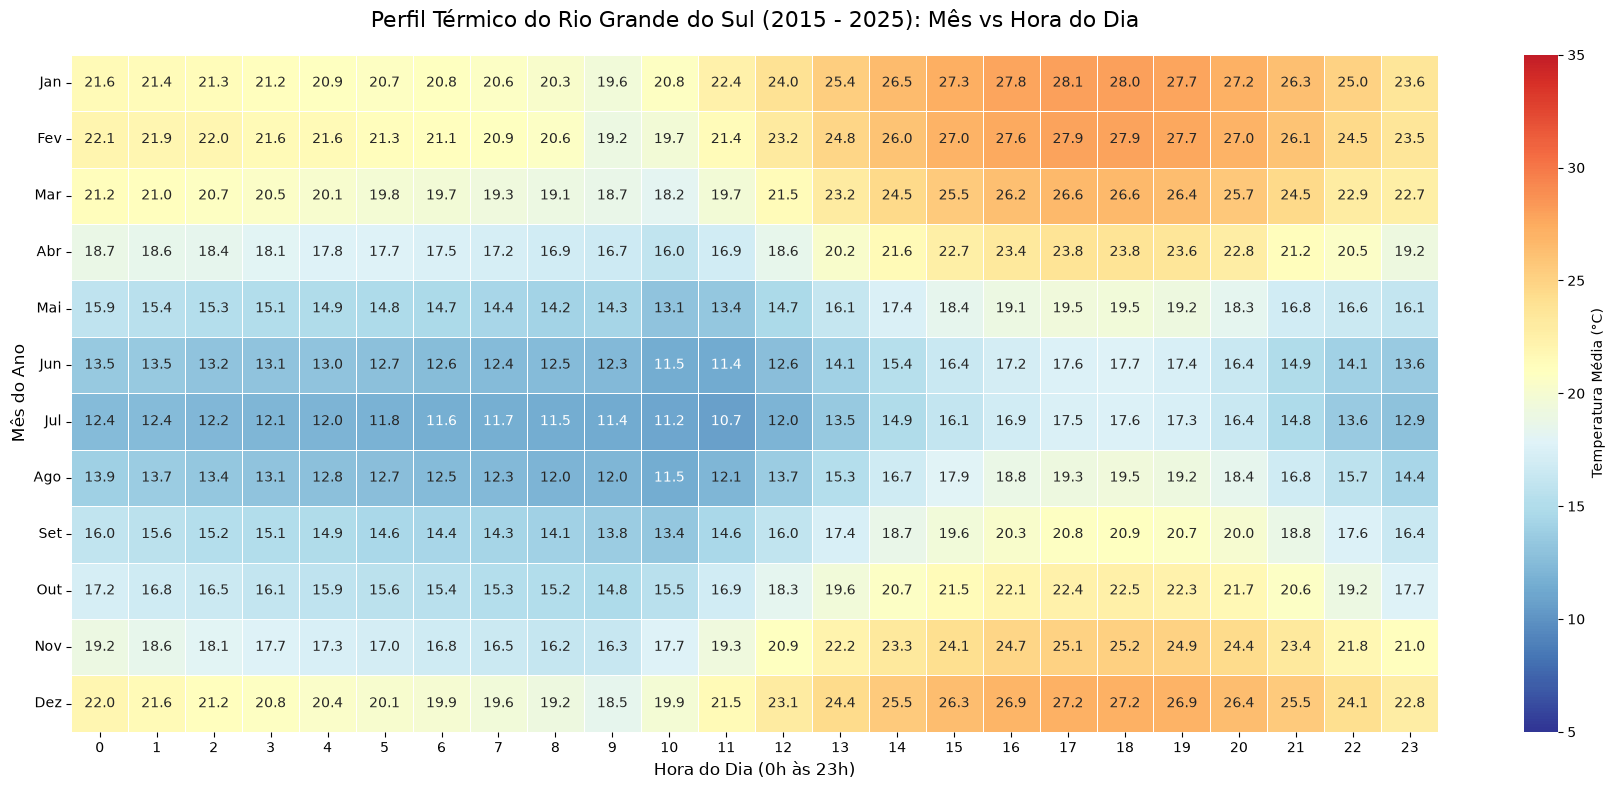

In [39]:
diretorio_imagem = os.path.join(PASTA_GRAFICOS,"fig_mapa_calor_RS.png")

plt.close('all') # Fecha qualquer gráfico residual da memória# Lista de estados únicos

# Agrupa os dados por Mês e Hora e calcula a média da temperatura
# O pivot_table já faz o agrupamento (média) automaticamente para valores duplicados
df_pivot_rs = df_rs.pivot_table(index='mes', columns='hora_utc', values='temperatura_ar', aggfunc='mean')

# Garante que os meses estão ordenados corretamente
df_pivot_rs = df_pivot_rs.reindex(range(1,13))

# 4. Configurar e desenhar o Heatmap
plt.figure(figsize=(18, 8))

# Criar o heatmap usando uma paleta térmica ('coolwarm' é ideal para temperatura)
sns.heatmap(
    df_pivot_rs, 
    cmap='RdYlBu_r', 
    vmin=5,
    vmax=35,
    center=21,
    annot=True, 
    fmt=".1f", 
    linewidths=.5, 
    cbar_kws={'label': 'Temperatura Média (°C)'}
)

# Títulos e formatação dos eixos
plt.title('Perfil Térmico do Rio Grande do Sul (2015 - 2025): Mês vs Hora do Dia', fontsize=16, pad=20)
plt.xlabel('Hora do Dia (0h às 23h)', fontsize=12)
plt.ylabel('Mês do Ano', fontsize=12)

# Substituir os números dos meses pelos nomes para melhor leitura
nomes_meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
plt.yticks(ticks=np.arange(12) + 0.5, labels=nomes_meses, rotation=0)
plt.xticks(ticks=np.arange(24) + 0.5, labels=list(range(24)), rotation=0)

# Exibir o gráfico
plt.tight_layout()
plt.savefig(diretorio_imagem, dpi=300, bbox_inches='tight')
plt.show()

Para exibir os heatmaps dos 3 estados lado a lado é necessário que as cores sigam um padrão para não ocorrer variação para uma mesma temperatura.
Para isso vmin e vmax dinâmicos são utilizados para calcular automaticamente a menor e a maior temperatura entre os três estados, de forma a garantir que a paleta (cmap) seja justa na comparação visual.

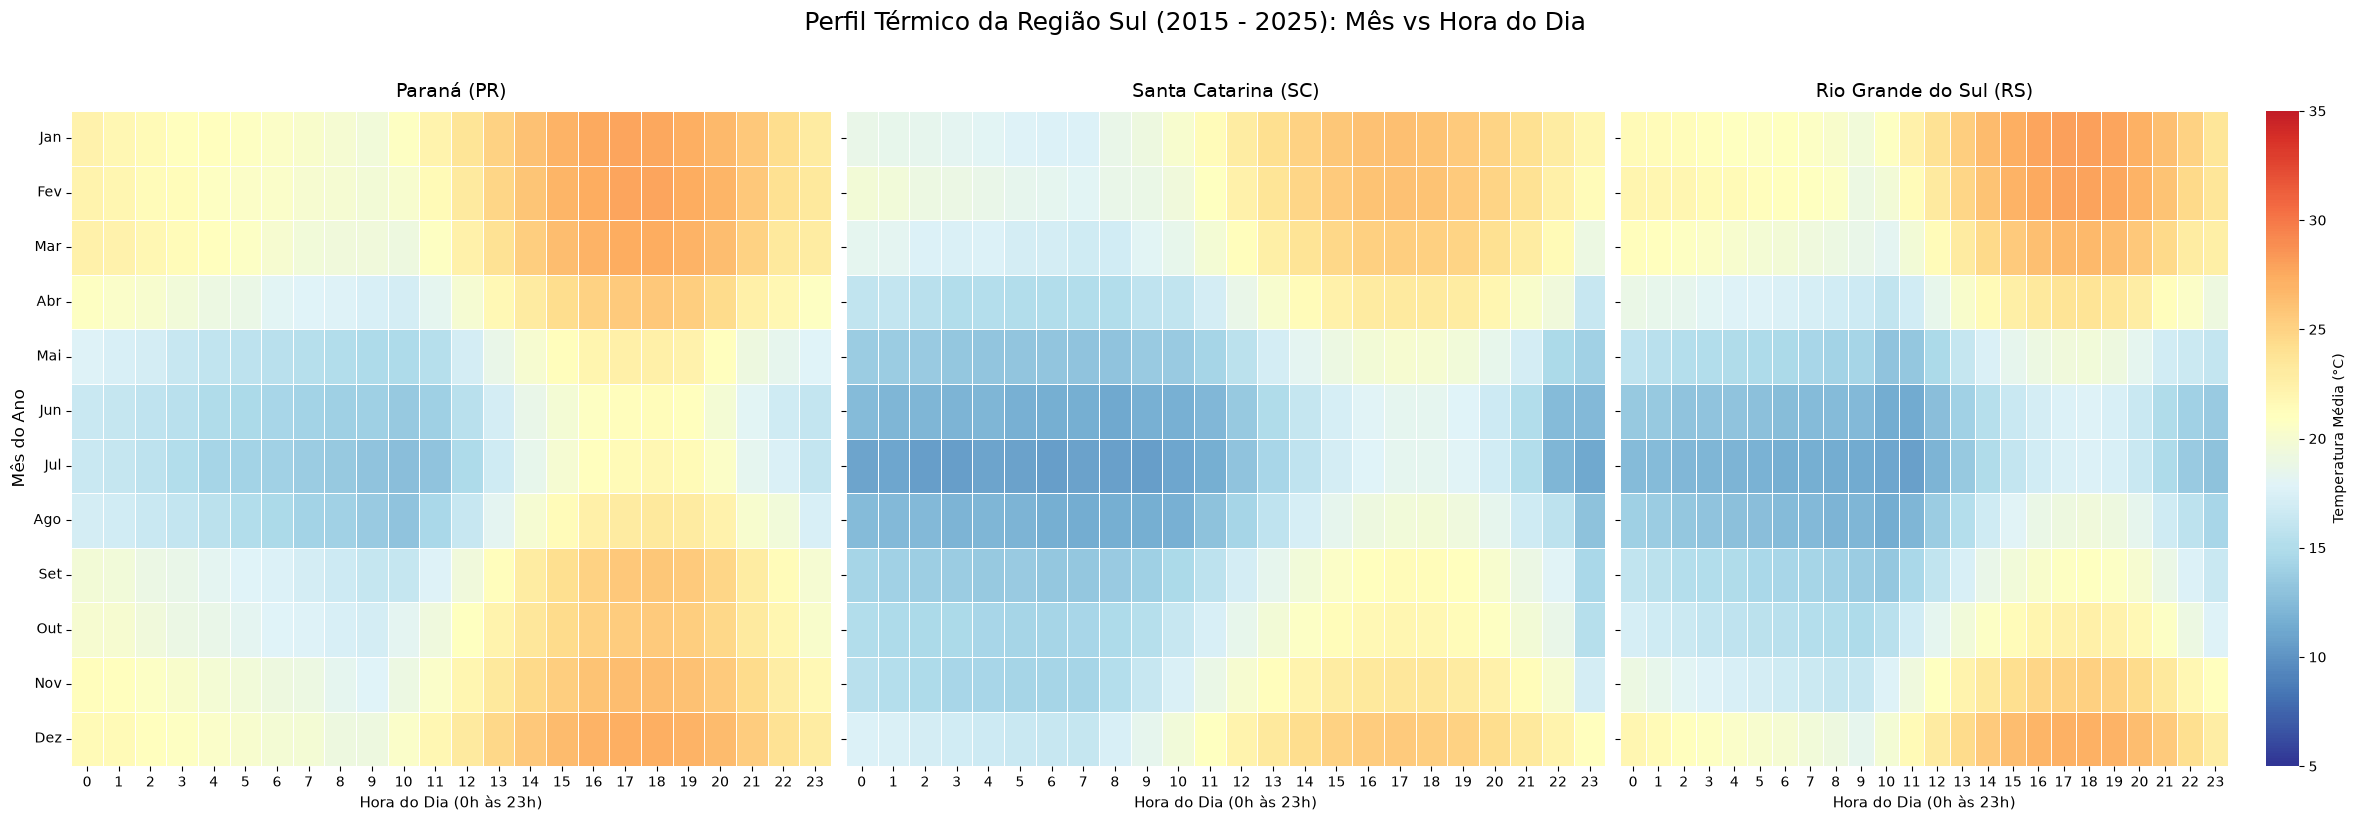

In [42]:
diretorio_imagem = os.path.join(PASTA_GRAFICOS,"fig_mapa_calor_todos.png")

plt.close('all') 

# Gera as tabelas pivô para os três estados
df_pivot_pr = df_pr.pivot_table(index='mes', columns='hora_utc', values='temperatura_ar', aggfunc='mean')
df_pivot_sc = df_sc.pivot_table(index='mes', columns='hora_utc', values='temperatura_ar', aggfunc='mean')
df_pivot_rs = df_rs.pivot_table(index='mes', columns='hora_utc', values='temperatura_ar', aggfunc='mean')


# Configura a grade (1 linha, 3 colunas)
# sharey=True remove os nomes dos meses dos gráficos do meio e da direita para economizar espaço
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)

# Lista auxiliar para facilitar o loop de estilização dos eixos
pivots = [df_pivot_pr, df_pivot_sc, df_pivot_rs]
titulos = ['Paraná (PR)', 'Santa Catarina (SC)', 'Rio Grande do Sul (RS)']
nomes_meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

# Desenha os heatmaps
for i, ax in enumerate(axes):
    # Passa o 'ax', vmin e vmax, e exibe a cbar apenas no último gráfico para limpar o visual
    sns.heatmap(
        pivots[i], 
        cmap='RdYlBu_r', 
        vmin=5,
        vmax=35,
        center=21,
        annot=False, 
        fmt=".1f", 
        linewidths=.5, 
        ax=ax,
        cbar=(i == 2), # Exibe a barra de cores apenas no terceiro gráfico
        cbar_kws={'label': 'Temperatura Média (°C)'} if i == 2 else None)
    
    # Título individual de cada estado
    ax.set_title(titulos[i], fontsize=14, pad=10)
    
    # Formatação do eixo X (Hora)
    ax.set_xlabel('Hora do Dia (0h às 23h)', fontsize=11)
    ax.set_xticks(np.arange(24) + 0.5)
    ax.set_xticklabels(list(range(24)), rotation=0)

# Formatação do eixo Y (Mês) - Aplicado apenas no primeiro gráfico devido ao sharey=True
axes[0].set_ylabel('Mês do Ano', fontsize=12)
axes[0].set_yticks(np.arange(12) + 0.5)
axes[0].set_yticklabels(nomes_meses, rotation=0)
axes[1].set_ylabel('')
axes[2].set_ylabel('')

# Título geral superior para a imagem inteira
plt.suptitle('Perfil Térmico da Região Sul (2015 - 2025): Mês vs Hora do Dia', fontsize=18, y=1.02)

# Salva e exibe
plt.tight_layout()
plt.savefig(diretorio_imagem, dpi=300, bbox_inches='tight')
plt.show()


A escala divergente foi centralizada próxima à temperatura média climatológica dos três estados no período analisado.

A intenção do gráfico acima é exibir um comparativo visual da média das temperaturas nos três estados ao longo do ano e das horas do dia. 

Vemos o gráfico com um formato de ampulheta com as médias de temperatura nos meses mais frios (maio a agosto) no PR apresentando temperaturas mais quentes entre os horários das 14 às 20h em comparação a SC e RS, sendo este último com pouco alívio no frio. Entre os três estados observa-se que SC apresentou mais períodos de temperatura baixa.

## Análise dos Ventos

In [53]:
# Copia o dataframe original e agrupa
df_vento = df_limpo.copy()

# Cria uma coluna de mês
df_vento['mes'] = df_vento['data'].dt.month
df_vento['vento_velocidade'] = df_vento['vento_velocidade'] * 3.6 # Converte em Km/h


# O parâmetro freq='ME' (Month End, ou fim do mês) em pd.Grouper agrupa dados de séries temporais 
# em intervalos mensais baseados no calendário, atribuindo a cada grupo como rótulo a data exata 
# do último dia do respectivo mês.
df_vento = df_vento.groupby(['uf', pd.Grouper(key='data', freq='ME')])['vento_velocidade'].agg(['mean', 'max', 'min']).reset_index()

# Ordena cronologicamente
df_vento = df_vento.sort_values('data')

In [70]:
fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=("Paraná", "Santa Catarina", "Rio Grande do Sul")
)

cores = {
    'PR': {'linha': 'rgb(31,119,180)'},
    'SC': {'linha': 'rgb(44,160,44)'},
    'RS': {'linha': 'rgb(214,39,40)'}
}

estados = ["PR", "SC", "RS"]

for i, estado in enumerate(estados, start=1):

    df_estado = df_vento[df_vento["uf"] == estado]

    # média
    fig.add_trace(
        go.Scatter(
            x=df_estado["data"],
            y=df_estado["mean"],
            mode="lines",
            line=dict(color=cores[estado]["linha"], width=2.5),
            name=f"Média {estado}",
            xhoverformat="%b %Y",
            hovertemplate="Média: %{y:.1f} Km/h<extra></extra>",
            #hovertemplate="<b>%{x|%b %Y}</b><br>Média: %{y:.1f}°C<extra></extra>"
        ),
        row=i, col=1
    )

    fig.add_trace(
        go.Scatter(
            x=df_estado["data"],
            y=df_estado["max"],
            mode="lines",
            line=dict(
                color=cores[estado]['linha'],
                width=1,
                dash='dot'
            ),
            name=f"Maxima {estado}",
            xhoverformat="%b %Y",
            hovertemplate="Máx: %{y:.1f} Km/h<extra></extra>",
        ),
        row=i, col=1
    )


# Configuração do layout geral e do Hover Sincronizado com Caixas Separadas
fig.update_layout(
    title="Evolução Histórica da Velocidade dos Ventos por Estado",
    height=900,
    hovermode="x",             # Mantém as caixas flutuantes separadas por gráfico
    plot_bgcolor="white",
    hoverlabel=dict(
        bgcolor="white",
        font_size=12
    )
)



fig.update_xaxes(
    dtick="M12", # Exibe o rótulo de x com intervalos de 1 ano
    tickformat="%Y",
    showgrid=True,
    gridcolor="lightgray",
    showspikes=True,
    spikesnap="cursor",
    spikecolor="gray",
    spikethickness=1,
    spikedash="solid",
    spikemode="across",
    hoverformat="%b %Y"
)

# Atualiza o eixo x para exibir os rótulos de ano apenas no último gráfico
fig.update_xaxes(showticklabels=False, row=1, col=1)
fig.update_xaxes(showticklabels=False, row=2, col=1)
fig.update_xaxes(showticklabels=True, row=3, col=1)



# Configurações de grade dos eixos Y individuais
fig.update_yaxes(
    showgrid=True, 
    gridcolor="lightgray", 
    title="Km/h", 
    range=[0, 110]
)

fig.show()

In [44]:
vel_rajada = df_limpo['vento_rajada'].max()
data = df_limpo.loc[df_limpo['vento_rajada'].idxmax(), 'data'].strftime('%d/%m/%Y')
hora = df_limpo.loc[df_limpo['vento_rajada'].idxmax(), 'hora_utc'].strftime('%H')
uf = df_limpo.loc[df_limpo['vento_rajada'].idxmax(), 'uf']
nome_estacao = df_limpo.loc[df_limpo['vento_rajada'].idxmax(), 'nome_estacao']

f" A maior velocidade de rajada de vento foi de {vel_rajada*3.6} Km/h em {data} às {hora} h no estado {uf} registrado na estação {nome_estacao}"

' A maior velocidade de rajada de vento foi de 161.28 Km/h em 05/04/2017 às 11 h no estado RS registrado na estação VACARIA'

Na escala de [Beaufort](https://pt.wikipedia.org/wiki/Escala_de_Beaufort), que classifica a intensidade dos ventos tendo em conta a sua velocidade e os efeitos resultantes das ventanias no mar e em terra, e que vai de 0 - Calmo/Calmaria até 12 - Furacão, a velocidade de 161.28 Km/h é classificada como:
| Grau | Designação | m/s| km/h | nós| Aspecto do mar |Efeitos em terra |
| -- | -- | -- | -- | -- | -- | --|
| 12 |Furacão |	≥32,7 | ≥118 | ≥64 | Mar todo de espuma, com até 14 m; visibilidade nula | Estragos graves e generalizados em construções |

## Engenharia de Dados: Arquitetura e Otimização de Performance

Um dos maiores desafios deste projeto não foi a análise estatística em si, mas o processamento da base bruta do INMET de forma eficiente.

Os dados históricos do INMET são distribuídos em arquivos '.zip' anuais; alguns deles também contém uma pasta com o ano do dado. Dentro de cada ZIP, existem centenas de arquivos '.csv' minúsculos (um para cada estação meteorológica). 
* **Abordagem Inicial (Naïve):** Um loop sequencial tradicional em Python lê um arquivo por vez. O tempo total de execução para consolidar a Região Sul foi de **1m 33.9s**.
* **A Falsa Solução (Chunking):** Estratégias de leitura em pedaços (*chunksize*), comuns para arquivos gigantes (como os da PRF), aqui gerariam *overhead*, pois os arquivos individuais já são pequenos (~8.760 linhas). O verdadeiro gargalo era o I/O sequencial e o tratamento de texto no loop principal.

### A Solução Arquitetural
Para resolver o gargalo, foi desenhada uma arquitetura de processamento paralelo utilizando **Polars** (motor em Rust com liberação nativa do GIL) combinado com o `ThreadPoolExecutor` do Python.

1. **Paralelização por Escopo Correto (ZIP/Ano):** Em vez de abrir o mesmo arquivo ZIP centenas de vezes para cada estação (gerando gargalo de disco), o paralelismo foi aplicado no nível do arquivo ZIP. Cada thread abre um ano específico uma única vez.
2. **Tratamento Descentralizado (*Worker-level*):** Toda a limpeza pesada (substituição de strings `","` por `"."`, conversão de tipos para `Float64` e inputação de `None` nos valores `-9999.0`) foi movida para dentro do *worker*. Isso garantiu que o estresse de CPU ocorresse 100% em paralelo.
3. **Concatenação Limpa:** A função principal apenas recebe os DataFrames já tipados e limpos, executando um `pl.concat()` instantâneo e gerando o arquivo final em formato **Parquet**.

### 📊 Resultados de Performance

A tabela abaixo compara o ganho obtido após as iterações de refatoração do código:

| Abordagem | Estratégia | Tempo de Execução | Ganho de Velocidade |
| :--- | :--- | :--- | :--- |
| **V1 (Inicial)** | Sequencial Puro | 1m 33.9s | Base (1x) |
| **V2 (Refatorada)** | Threads por CSV (Gargalo de I/O) | 1m 27.7s | +6.6% |
| **V3 (Final)** | **Threads por ZIP + Limpeza no Worker** | **36.5s** | **+61.1% (🚀 2.5x mais rápido)** |

> 💡 **Nota de Arquitetura:** O arquivo Parquet resultante nasce 100% tipado e compactado. Sua leitura no ambiente de análise (Notebook) leva **menos de 2 segundos**, eliminando a necessidade de qualquer "faxina" de dados durante a exploração do analista.